In [1]:
import numpy as np
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi

## **Problema Deutsch-Jozsa**

- Input: $f : \{0, 1 \}^n \to \{0, 1 \} $
- Promesa: $f$ es constante o balanceada.
- 0 Si $f$ es constante.
- 1 si $f$ es balanceada.

Si TODOS los outputs del circuito son 0 entonces es constante. Si este no es el caso, entonces es balanceada.

También es posible realizar un post-procesado clásico y computar el **OR** lógico de todos los resultados.

In [84]:
def dj_query(num_qubits):
    
    qc = QuantumCircuit(num_qubits + 1)
    
    if np.random.randint(0, 2):
        # Modificar el qubit de output con probabilidad 1/2
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # Devolver el circuito constante con probabilidad 1/2
        return qc
    
    # Escoger la mitad de los posibles inputs
    on_states = np.random.choice(
        range(2**num_qubits), # Número total del que se extraen las "samples"
        2**num_qubits // 2, # Número de "samples"
        replace = False, # Los estados solo son "sampled" una vez
    )
    
    # El siguiente método añade puertas de inversión a aquellos qubits afectados
    # por los samples anteriores, esencialmente aplicando la función.
    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc
    
    
    # Para todos los estados que han sido afectados por el cambio de input
    # Se añade la negación en los qubits afectados, la puerta controlada de
    # múltiples controladores, y la negación posterior para que cambie para
    # el siguiente estado de la función, efectivamente reiniciándolo.
    for state in on_states:
        qc.barrier()
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")
    
    qc.barrier()
    
    return qc

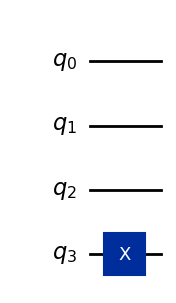

In [86]:
display(dj_query(3).draw(output="mpl"))

A continuación, una función que crea el circuito de Deutsch-Jozsa, tomando como input la implementación de un circuito de una query:

In [87]:
def compile_circuit(function: QuantumCircuit):

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(function, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

Finalmente una función que ejecuta el circuito cuando este esté definido:

In [88]:
def dj_algorithm(function: QuantumCircuit):
    # Determinar si una función es constante o balanceada

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

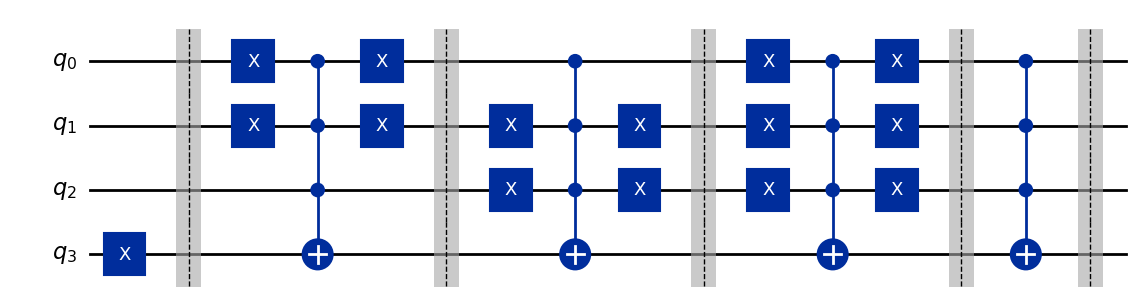

'balanced'

In [91]:
f = dj_query(3)
display(f.draw("mpl"))
display(dj_algorithm(f))